In [1]:
import setuptools.dist
import sys


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from yellowbrick.regressor import ResidualsPlot

In [2]:
# Carregamento da base de dados e exclusão da primeira coluna.

base = pd.read_csv('C:/Users/mrwag/OneDrive/Big Data/DS/21.Textos/cars.csv')
base.shape

(50, 3)

In [3]:
base.head()

,Unnamed: 0,speed,dist
0,1,4,2
1,2,4,10
2,3,7,4
3,4,7,22
4,5,8,16


In [4]:
# Exclusão da primeira coluna.

base = base.drop(['Unnamed: 0'], axis = 1)
base.head()

,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


In [5]:
# Criação das variáveis, sendo x a distância = variável independente.
# sendo y a velocidade = variável dependente.

X = base.iloc[:, 1].values
Y = base.iloc[:, 0].values

In [6]:
# Cálculo da correlação entre X e Y.

correlacao = np.corrcoef(X, Y)
correlacao

array([[1.       , 0.8068949],
       [0.8068949, 1.       ]])

In [7]:
# Formato de matriz com uma coluna a mais.

X = X.reshape(-1, 1)

# Criação do modelo e treinamento com o comando fit().

modelo = LinearRegression()
modelo.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
# Visualização dos coeficientes.

modelo.intercept_

np.float64(8.283905641787172)

In [9]:
# Inclinação.

modelo.coef_

array([0.16556757])

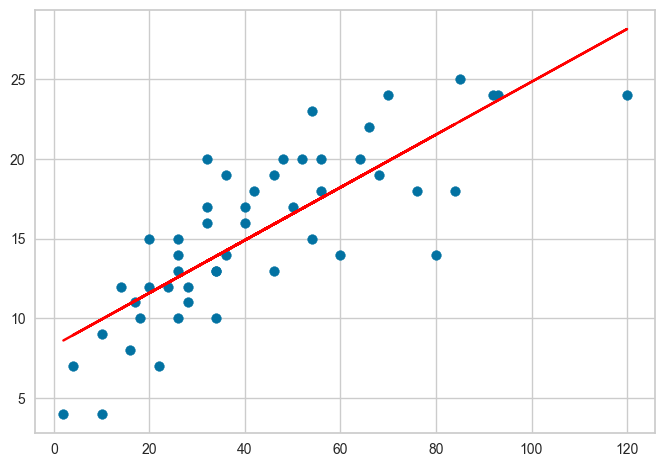

In [10]:
# Criação do gráfico com pontos reais e previsões.

plt.scatter(X, Y)
plt.plot(X, modelo.predict(X), color = 'red')

In [11]:
# Previsão da distância de 22 pés usando a fórmula manual.
# interceptação + inclinação * distância.
# Qual a velocidade se demorou 22 pés para parar?

modelo.intercept_ + modelo.coef_ * 22

array([11.92639228])

In [12]:
# Previsão com a função do Sklearn.

modelo.predict([[22]])

array([11.92639228])

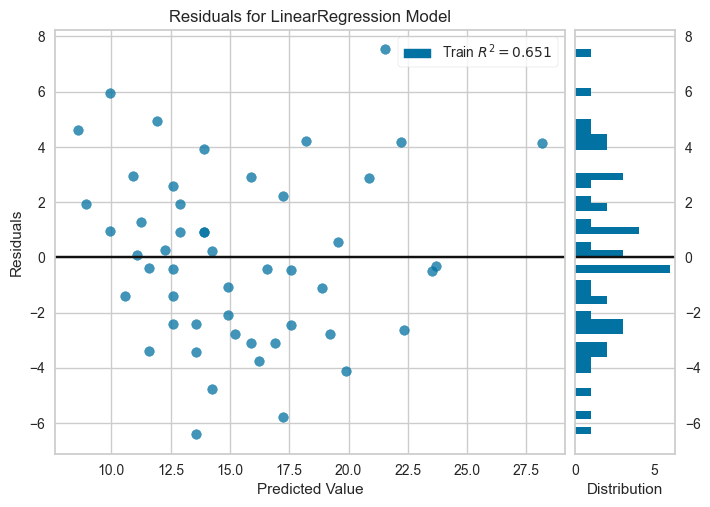

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [13]:
# Gráfico para visualizar os residuais.

visualizador = ResidualsPlot(modelo, force_model = True) # Usei o force_model para forçar o reconhecimento da regressão linear.
visualizador.fit(X, Y)
visualizador.poof()